In [1]:
import os
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd

from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import *
from src.dataPreProcessing import replace_nan


# Remove null values df. dropna(inplace=True)

# if variables are changed on the fly 
from reloading import reloading
from tqdm.notebook import tqdm

In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

In [3]:
N_PASTS, n_lags, n_perm = list(range(3, 7)), 2, 10000
# alpha, beta = 0.05, 0.005

In [4]:
%%time

# load data
os.chdir(r'./data/fMRI_sims/')
# names = [n for n in os.listdir() if n.endswith('.csv')]
names = ['timeseries4.csv']
INFs = {}
for i in range(len(names)):
    print('Data ' + names[i])
    print('')
    
    X_ = pd.read_csv(names[i], header=None)
    X = X_.values.T
    
    # Analysis
    infs = []
    for a, n in enumerate(N_PASTS):
        
        print(f'{n} pasts')
        gcstar = GcStar(n_perm = 10000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = 'fcgc')
    
        gcstar.fit(X, verbose = 0)
        inf = gcstar.get_connectivity_matrix(alpha=0.001, beta = 0.0001, simulation=False)
        np.fill_diagonal(inf, 0)
        infs.append(inf)
        
    print('')
    print('')
    INFs[i] = infs

Data timeseries4.csv

3 pasts


C:\Users\sadiq\Documents\GC-extension\examples\..\src\d_CSL.py:32: NumbaExperimentalFeatureWarning: Use of isinstance() detected. This is an experimental feature.
  corr_1 = np.corrcoef(x, y)[1, 0]


4 pasts
5 pasts
6 pasts


CPU times: total: 8h 22min 6s
Wall time: 1h 35min 38s


KeyError: 1

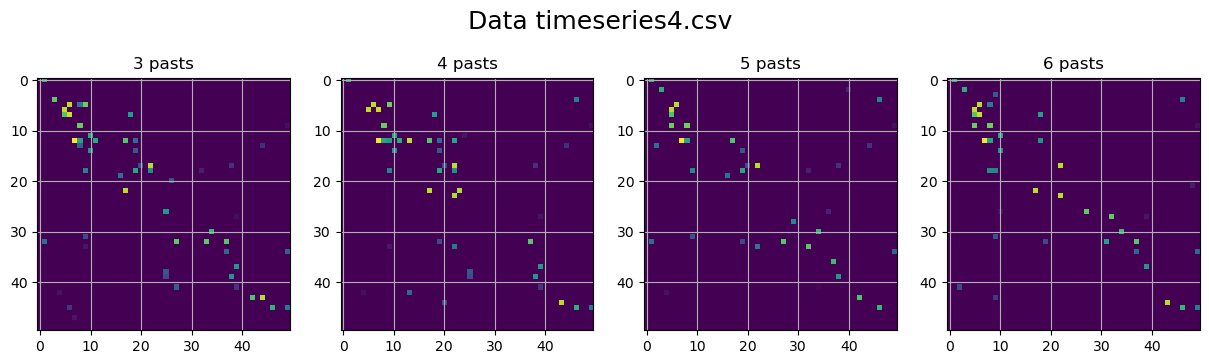

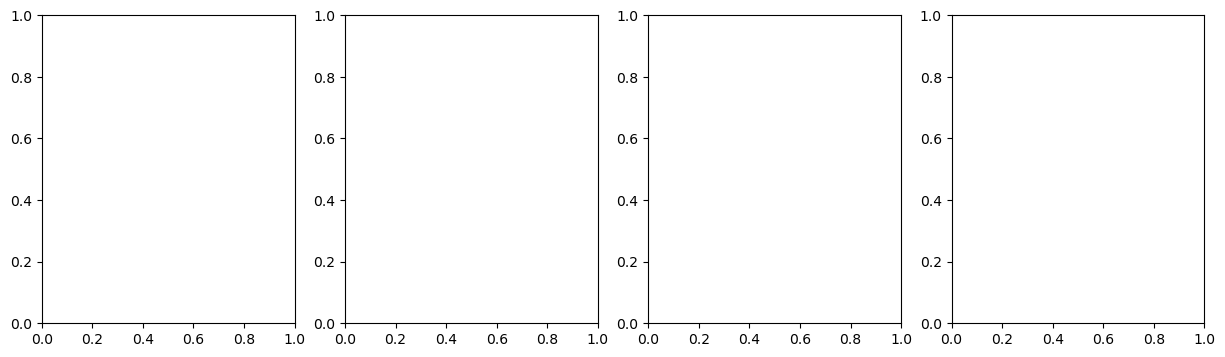

In [5]:
for i in range(28):
  fig,ax = plt.subplots(1,4,figsize=(15,4))
  for j in range(4):
    ax[j].imshow(INFs[i][j])
    ax[j].set_title(f'{j+3} pasts')
#     ax[j].set_xticks(np.arange(INFs[i][j].shape[0]))
#     ax[j].set_yticks(np.arange(INFs[i][j].shape[0]))
#     ax[j].set_xticklabels(pro,rotation=90)
#     ax[j].set_yticklabels(pro)
    ax[j].grid()
  plt.suptitle(f'Data {names[i]}', fontsize=18)
  # print('')
  # print('')
plt.tight_layout()